In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import glob
from matplotlib import pyplot as plt

In [ ]:
timeslice1 = '1940-01-01'
timeslice2 = '2026-01-01'

# currently, the 'set climatology' is from 1940 instead of 1990s, does this matter?

# code from Michelle https://github.com/michellelheureux/Relative-SST/blob/main/compute_relativeNino34_ONI_JClimate.ipynb


In [ ]:
path_origins = '/Users/kaijz/Desktop/NOAA/data/'
name_file = 'sst.mnmean.nc' #ERSST monthly mean 

dataset_raw = xr.open_dataset(f'{path_origins}{name_file}')
dataset_raw = dataset_raw.drop_vars('time_bnds')

dat = dataset_raw.sel(time=slice(timeslice1, timeslice2)) # end exclusive?


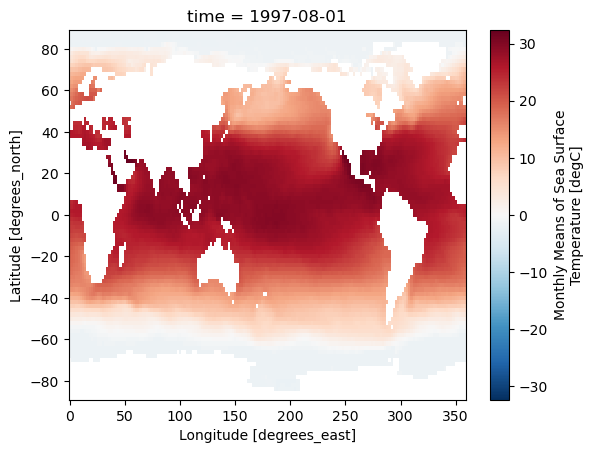

In [13]:
dataset_raw

dat.sel(time='1997-08-01T00:00:00.000000000')['sst'].plot()

# Tropical Mean index (total)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Text(0.5, 1.0, 'Tropical SST Average Index')

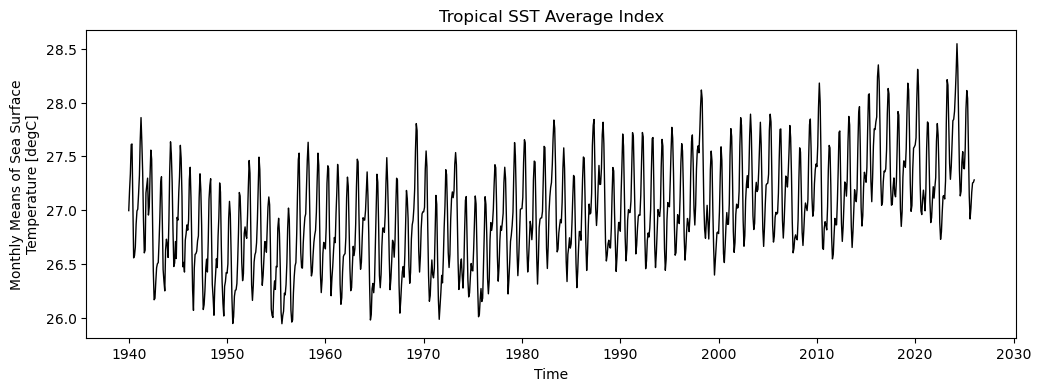

In [5]:
tropdomain = dat.sel(lat=slice(20, -20), lon=slice(0, 360))
tropav = tropdomain.mean(dim=('lat','lon'))
tropav = tropav.rename({'sst':'tropav'})

fig, ax = plt.subplots(figsize=(12, 4))
tropav.tropav.plot(ax=ax,x='time',linewidth=1,color='black')
plt.title('Tropical SST Average Index')

# Nino-3.4 index (total)

Text(0.5, 1.0, 'Nino-3.4 Average Index')

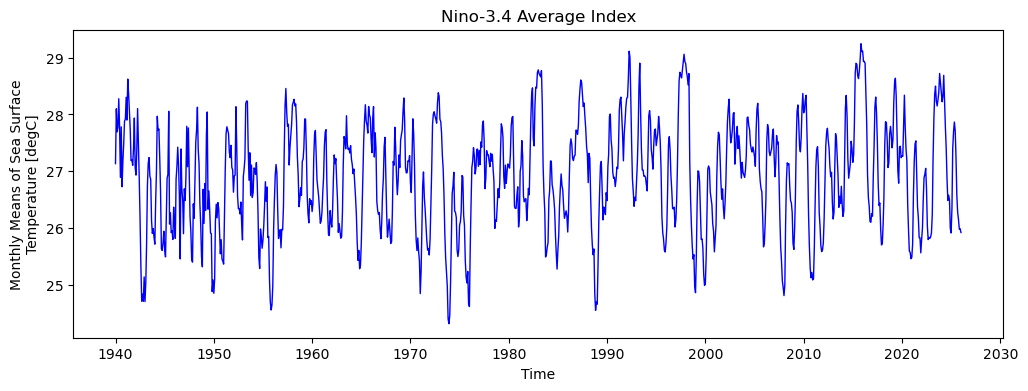

In [6]:
ninodomain = dat.sel(lat=slice(5, -5), lon=slice(190, 240))
nino34 = ninodomain.mean(dim=('lat','lon'))
nino34 = nino34.rename({'sst':'nino34'})

fig, ax = plt.subplots(figsize=(12, 4))
nino34.nino34.plot(ax=ax,x='time',linewidth=1,color='blue')
plt.title('Nino-3.4 Average Index')

In [8]:
# Set climatology 
climrang1 = timeslice1
climrang2 = timeslice2

# Nino3.4 anomaly
clm = nino34.sel(time=slice(climrang1,climrang2)).groupby('time.month').mean(dim='time')
nino34a = (nino34.groupby('time.month') - clm)
# Trop mean anomaly
clm = tropav.sel(time=slice(climrang1,climrang2)).groupby('time.month').mean(dim='time')
tropa = (tropav.groupby('time.month') - clm)

# Subtract tropical mean anomaly from Nino3.4 anomaly then apply scaling to match original variance

In [9]:
diff_idx = nino34a['nino34'] - tropa['tropav']

# Adjust variance 
f = nino34a.sel(time=slice(timeslice1, timeslice2))
r = diff_idx.sel(time=slice(timeslice1, timeslice2))
scaling_factor = f.groupby('time.month').std('time') / r.groupby('time.month').std('time')
scaled_reln34a = diff_idx.groupby('time.month') * scaling_factor
scaled_reln34a = scaled_reln34a.rename({'nino34':'relnino34a'})

Text(0.5, 1.0, 'Monthly Standard Deviation')

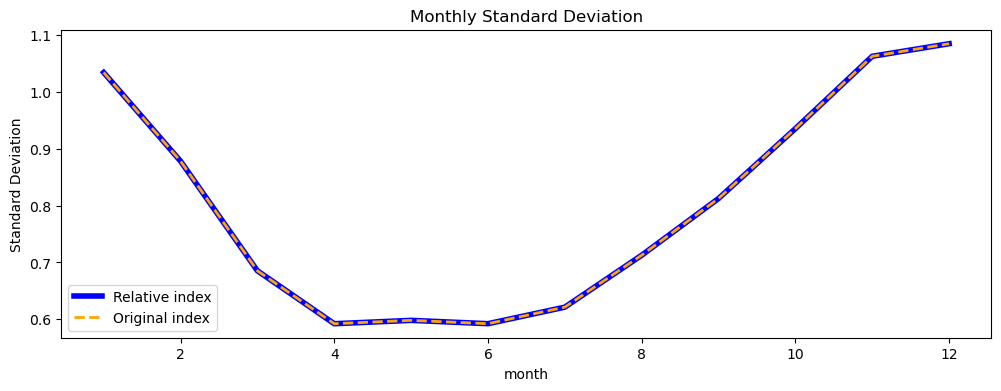

In [10]:
# test variance by month

relvar = scaled_reln34a.groupby('time.month').std('time')
origvar = nino34a.groupby('time.month').std('time')

fig, ax = plt.subplots(figsize=(12, 4))
relvar.relnino34a.plot(ax=ax,x='month',linewidth=4,color='blue',label='Relative index')
origvar.nino34.plot(ax=ax,x='month',linewidth=2,color='orange',linestyle='dashed',label='Original index')
plt.legend()
plt.ylabel('Standard Deviation')
plt.title('Monthly Standard Deviation')

## Compute Relative ONI (3 month running mean) and compare to ONI. Time now refers to centered month of season.

In [11]:
RONI = scaled_reln34a.rolling(time=3, center=True).mean()
RONI = RONI.dropna(dim="time", how="any") # drop nan
RONI = RONI.rename({'relnino34a':'RONI'})

ONI = nino34a.rolling(time=3, center=True).mean()
ONI = ONI.dropna(dim="time", how="any") # drop nan
ONI = ONI.rename({'nino34':'ONI'})

Text(0.5, 1.0, 'ONI and Relative ONI')

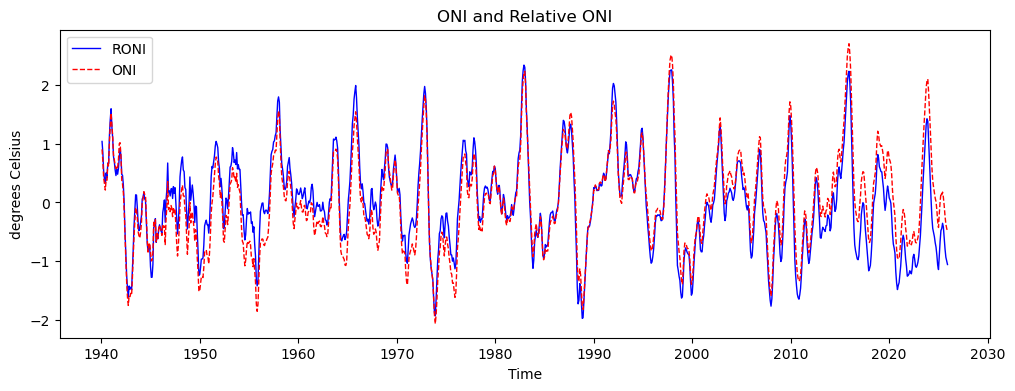

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
RONI.RONI.plot(ax=ax,x='time',linewidth=1,color='blue',label='RONI')
ONI.ONI.plot(ax=ax,x='time',linewidth=1,color='red',linestyle='dashed',label='ONI')
plt.legend()
plt.ylabel('degrees Celsius')
plt.title('ONI and Relative ONI')

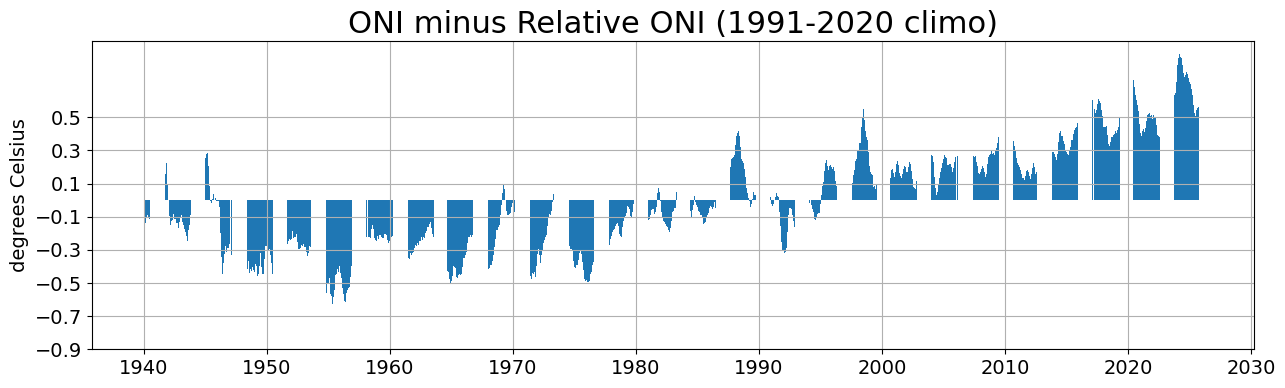

In [14]:
# plot differences

diff = ONI.ONI - RONI.RONI

fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(diff.time, diff.values, width=19.5)
ax.set_title('ONI minus Relative ONI (1991-2020 climo)',fontsize=22)
ax.set_ylabel('degrees Celsius',fontsize=14)
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_yticks(np.arange(-0.9, 0.6, step=.2))
ax.grid()

In [16]:
RONI.to_netcdf(f'{path_origins}{"RONI.nc"}')

In [ ]:
'''Step 1: ENSO regime classification (Takahashi):
1. Compute monthly SST anomalies over 10°S–10°N, full Pacific basin (lateral coasts), from 1940-2025
2. Extract leading two EOFs/PCs
3. Rotate 45° to get E and C indices: E = (PC1 − PC2)/√2, C = (PC1 + PC2)/√2.
4. Classify each month into ENSO regime states using thresholds on E and C (Takahashi uses |index| > 1σ; you may want to test multiple thresholds).
Also compute RONI and Niño 3.4 for comparison.'''